### GNSS-InSAR calibration of an OPERA DISP-S1 product

Venti grounds OPERA DISP-S1 line-of-sight (LOS) displacement in the GNSS reference
frame (IGS20). For each product it:

1. Builds the GNSS LOS displacement for the product's interval from the UNR gridded
   GNSS product (`constant`: rates × interval; `variable`: positions at both dates).
2. Removes signals GNSS does not contain **before** fitting: the tropospheric delay and
   the solid Earth tide layer shipped in each product (`/corrections/solid_earth_tide`).
3. Corrects unwrapping errors between disconnected regions and fills outliers.
4. Fits 30 km windowed planes to `InSAR − GNSS` and blends them into a smooth
   calibration surface.
5. Writes the surface in metres: **calibrated LOS = raw `/displacement` − surface**.

The result stays in IGS20, plate motion included. Turning LOS into vertical motion is
covered in `vertical_land_motion.ipynb`.

**Example:** New York City, frame F08622, using the longest interval in the stack
(2016-07-16 → 2017-03-13, 240 days).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio

import venti
from venti.gnss import compute_gnss_los
from venti.io.raster import read_netcdf, read_netcdf_correction
from venti.workflow.calibration import (
    CalibrationWorkflow,
    find_reference_point,
    load_los_and_mask,
)
from venti.workflow.config import (
    AlgorithmParameters,
    CalibrationInputGroup,
    CalibrationOptions,
    ProcessingOptions,
    ProductPathGroup,
    RunConfig,
    VentiConfig,
)
from venti.workflow.utils import (
    get_file_dates,
    match_correction_to_displacement,
    parse_window_size_meters,
)

venti.configure_logging()  # Venti's progress messages, shown below each cell

<Logger venti (INFO)>

### Configuration

The same settings as a `runconfig.yaml` + `algorithm_parameters.yaml` pair
(`venti.workflow.config.load_config` reads those). Defaults not listed here:
solid Earth tide correction on, unwrapping-error correction on, IGS20.
Temporary files go to `<scratch_path>/tmp` and are removed after the run.

In [2]:
frame_dir = Path("/mnt/aurora-z0/cabrera/opera_vlm/data/nyc_08622/frame_08622")
output_dir = Path("/mnt/aurora-z0/cabrera/opera_vlm/data/nyc_08622/notebook_examples")

config = VentiConfig(
    run_config=RunConfig(
        calibration_input_group=CalibrationInputGroup(
            input_files=frame_dir / "disp_s1",
            los_file=frame_dir / "los" / "los_enu_frame_8622.tif",
            water_mask=frame_dir / "water_mask.tif",
            tropo_files=frame_dir / "tropo" / "tropo_corrections_32618",
        ),
        product_path_group=ProductPathGroup(
            product_path=output_dir / "calibrated",
            scratch_path=output_dir / "scratch",
        ),
    ),
    algorithm_parameters=AlgorithmParameters(
        processing_options=ProcessingOptions(cal_downsample_factor=6),
        calibration_options=CalibrationOptions(
            grid_type="constant",       # UNR linear-rate grid
            window_size_meters=30_000,
            posting_meters=30,
            recompute_gnss=False,       # reuse GNSS fields cached in product_path
        ),
    ),
)
print(config.algorithm_parameters.calibration_options.model_dump_json(indent=2))

{
  "grid_type": "constant",
  "reference_frame": "IGS20",
  "unwrap_error_correction": true,
  "apply_tropo_correction": true,
  "apply_solid_earth_tide_correction": true,
  "recompute_gnss": false,
  "window_size_meters": 30000.0,
  "posting_meters": 30.0,
  "event_mask_buffer_pixels": 0,
  "residual_outlier_mad_threshold": null,
  "residual_region_mad_threshold": null,
  "residual_region_min_pixels": 20,
  "mask_fit_residual_outliers": true,
  "weight_fit_by_gnss_uncertainty": false,
  "calibration_surface_smoothing_method": "gaussian",
  "calibration_surface_smoothing_sigma": null,
  "savitzky_golay": {
    "window_length": 51,
    "polyorder": 3
  }
}


### Calibrate one product

`run_single` downloads the GNSS stations (once), picks the reference pixel from the
average temporal coherence, and calibrates the file. The tropospheric corrections for
the two acquisition dates are matched by date.

In [3]:
disp_file = next(config.input_options.input_files.glob("*_20160716T225042Z_20170313T225042Z_*.nc"))
[(tropo_ref, tropo_sec, _)] = match_correction_to_displacement(
    sorted(config.input_options.tropo_files.glob("*.tif")), [disp_file]
)

workflow = CalibrationWorkflow(config=config)
state = workflow.run_single(disp_file, tropo_ref_file=tropo_ref, tropo_sec_file=tropo_sec)

surface_file = state.output_files[0]
with rasterio.open(surface_file) as src:
    surface = src.read(1)
    extent_km = np.array(src.bounds)[[0, 2, 1, 3]] / 1000
    print(surface_file.name)
    print("Band description:", src.descriptions[0])

2026-09-26 18:37:33,528 - venti.workflow.utils - INFO - Temporary files go to /mnt/aurora-z0/cabrera/opera_vlm/data/nyc_08622/notebook_examples/scratch/tmp/run_v67ry7i_


2026-09-26 18:37:33,528 - venti.workflow.calibration - INFO - ============================================================


2026-09-26 18:37:33,529 - venti.workflow.calibration - INFO - Starting Venti Single-File Calibration


2026-09-26 18:37:33,529 - venti.workflow.calibration - INFO - ============================================================


2026-09-26 18:37:33,529 - venti.workflow.calibration - INFO - Input file : /mnt/aurora-z0/cabrera/opera_vlm/data/nyc_08622/frame_08622/disp_s1/OPERA_L3_DISP-S1_IW_F08622_VV_20160716T225042Z_20170313T225042Z_v1.0_20260224T180332Z.nc


...

2026-09-26 18:38:11,759 - venti.workflow.calibration - INFO - ============================================================


2026-09-26 18:38:11,760 - venti.workflow.calibration - INFO - Single-File Calibration Complete


2026-09-26 18:38:11,760 - venti.workflow.calibration - INFO - ============================================================


2026-09-26 18:38:11,760 - venti.workflow.calibration - INFO - Output: /mnt/aurora-z0/cabrera/opera_vlm/data/nyc_08622/notebook_examples/calibrated/OPERA_L3_DISP-S1_IW_F08622_VV_20160716T225042Z_20170313T225042Z_v1.0_20260224T180332Z_calibration_surface_constant_igs20_downsample6_tropo_set.tif


OPERA_L3_DISP-S1_IW_F08622_VV_20160716T225042Z_20170313T225042Z_v1.0_20260224T180332Z_calibration_surface_constant_igs20_downsample6_tropo_set.tif
Band description: LOS calibration surface (constant GNSS model, IGS20 frame) with tropospheric correction with solid Earth tide correction


### What went into the surface

The surface is the sum of the corrections removed before the fit (tropospheric delay,
solid Earth tide), the reference-pixel offset, and the fitted long-wavelength
difference between InSAR and GNSS. Subtracting it from the raw product gives the
calibrated displacement."

Reading the panels: the tropospheric delay is a difference of total delays, so only
its variation across the frame matters (a constant cancels). The rectangle south of
Long Island is open water missed by the frame's water mask.

2026-09-26 18:38:13,599 - venti.workflow.calibration - INFO - Loading LOS unit vectors and mask...


2026-09-26 18:38:13,611 - venti.workflow.calibration - INFO - LOS and mask loaded


2026-09-26 18:38:15,310 - venti.io.raster - INFO - Read NetCDF: /mnt/aurora-z0/cabrera/opera_vlm/data/nyc_08622/frame_08622/disp_s1/OPERA_L3_DISP-S1_IW_F08622_VV_20160716T225042Z_20170313T225042Z_v1.0_20260224T180332Z.nc, variable=displacement, shape=(7959, 9587)


2026-09-26 18:38:16,749 - venti.gnss.reference - INFO - Loading cached GNSS LOS velocity from /mnt/aurora-z0/cabrera/opera_vlm/data/nyc_08622/notebook_examples/calibrated/gnss_los_velocity.npy


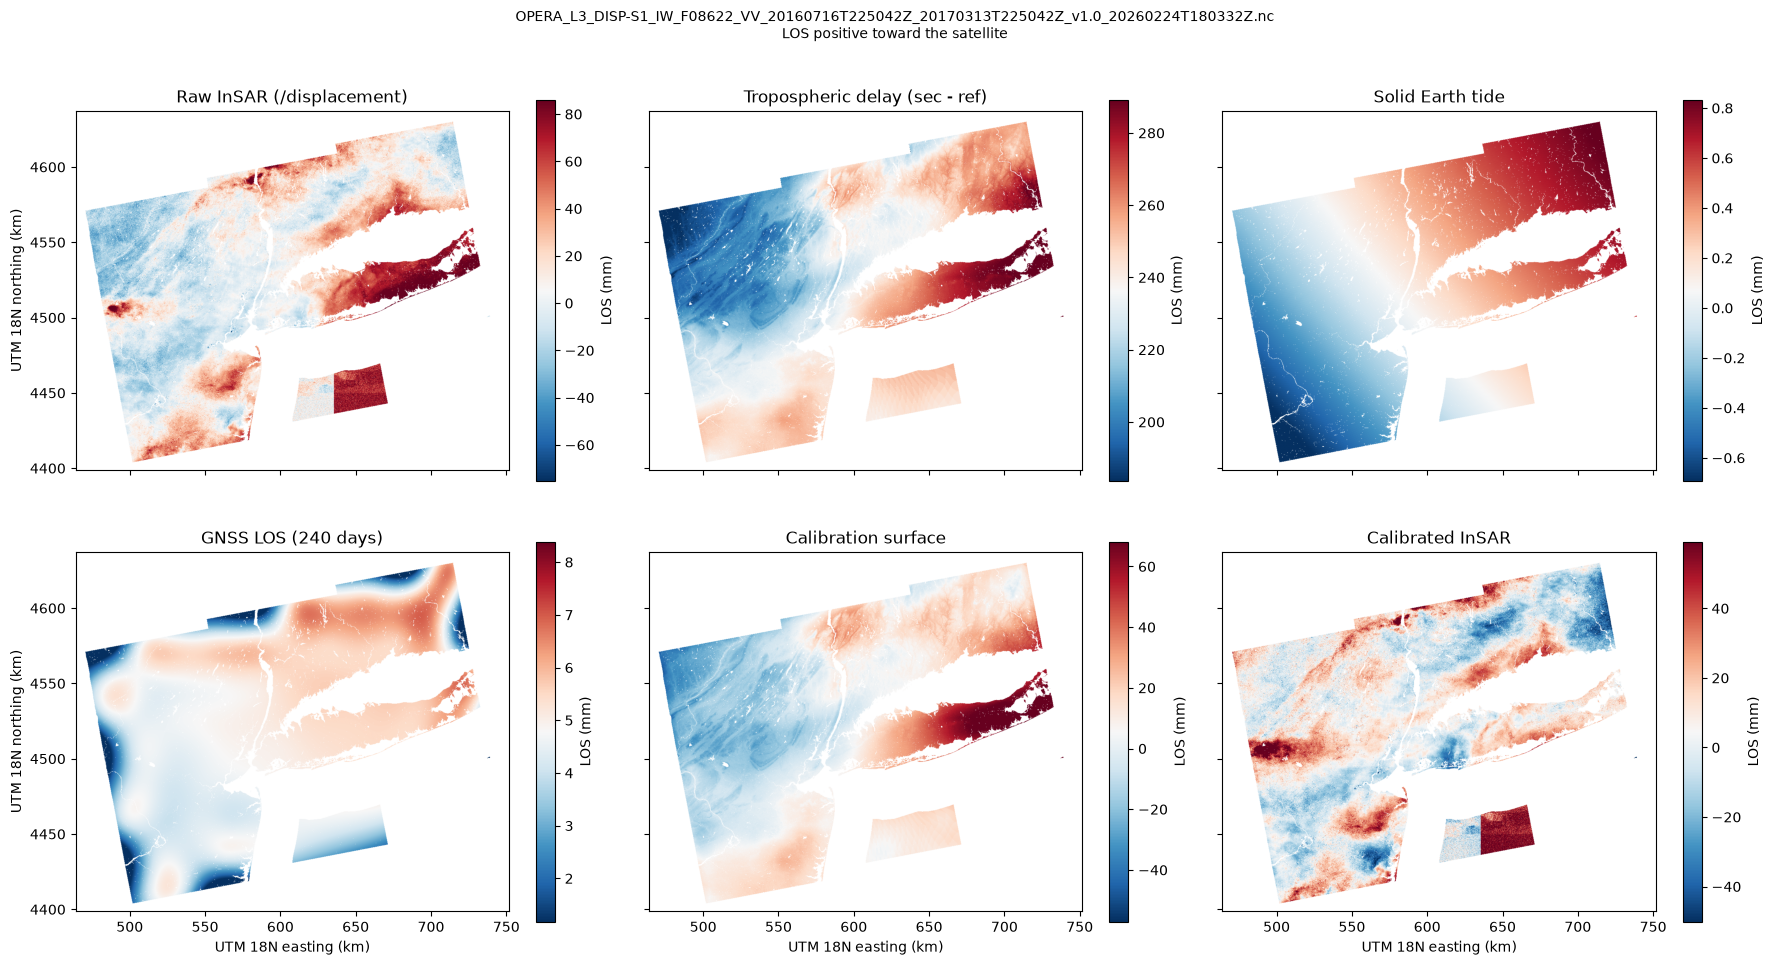

In [4]:
ref_date, sec_date = get_file_dates(disp_file)
los_east, los_north, los_up, mask = load_los_and_mask(
    workflow.io_reader, config.input_options.los_file, config.input_options.water_mask
)

disp = read_netcdf(disp_file, variable="displacement")[0]
with rasterio.open(tropo_ref) as ref, rasterio.open(tropo_sec) as sec:
    tropo = sec.read(1) - ref.read(1)
tide = read_netcdf_correction(disp_file, "solid_earth_tide")
gnss_los = compute_gnss_los(  # loads the cache the run just wrote (mm)
    workflow.gnss_manager, los_east, los_north, los_up, disp_file,
    cache_dir=config.run_config.product_path_group.product_path,
    ref_date=ref_date, sec_date=sec_date,
) / 1000
calibrated = disp - surface

valid = mask & np.isfinite(disp)
panels = {
    "Raw InSAR (/displacement)": disp,
    "Tropospheric delay (sec - ref)": tropo,
    "Solid Earth tide": tide,
    f"GNSS LOS ({(sec_date - ref_date) * 365.25:.0f} days)": gnss_los,
    "Calibration surface": surface,
    "Calibrated InSAR": calibrated,
}
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, (title, data) in zip(axes.flat, panels.items()):
    shown = np.where(valid, data * 1000, np.nan)[::8, ::8]
    lim = np.nanpercentile(np.abs(shown - np.nanmedian(shown)), 98)
    mid = np.nanmedian(shown)
    im = ax.imshow(shown, cmap="RdBu_r", vmin=mid - lim, vmax=mid + lim, extent=extent_km)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8, label="LOS (mm)")
for ax in axes[1]:
    ax.set_xlabel("UTM 18N easting (km)")
for ax in axes[:, 0]:
    ax.set_ylabel("UTM 18N northing (km)")
fig.suptitle(f"{disp_file.name}\nLOS positive toward the satellite", fontsize=10)
plt.tight_layout()
plt.show()

### Agreement with GNSS before and after

InSAR has no absolute zero, so both differences are compared after removing their
median. What remains after calibration is noise plus deformation the smooth GNSS
field does not resolve (e.g. local subsidence).

raw InSAR - GNSS         std  28.54 mm   5-95%:  -30.1 to  67.2 mm


calibrated InSAR - GNSS  std  20.09 mm   5-95%:  -27.9 to  37.5 mm


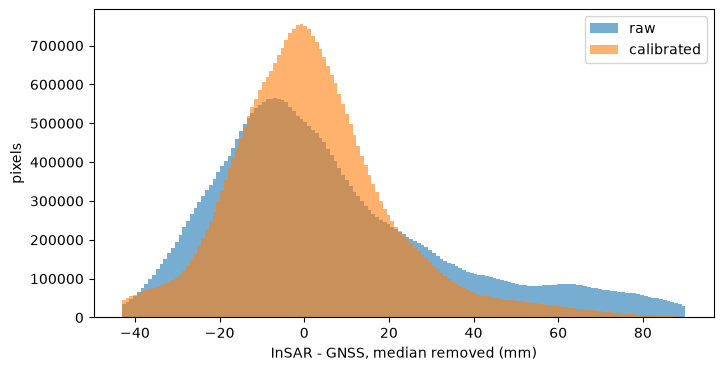

In [5]:
def centred(values):
    values = values[valid] * 1000
    return values - np.nanmedian(values)

before = centred(disp - gnss_los)
after = centred(calibrated - gnss_los)
for label, diff in [("raw InSAR - GNSS", before), ("calibrated InSAR - GNSS", after)]:
    p5, p95 = np.nanpercentile(diff, [5, 95])
    print(f"{label:24s} std {np.nanstd(diff):6.2f} mm   5-95%: {p5:6.1f} to {p95:5.1f} mm")

bins = np.linspace(*np.nanpercentile(before, [0.5, 99.5]), 150)
plt.figure(figsize=(8, 4))
plt.hist(before, bins, alpha=0.6, label="raw")
plt.hist(after, bins, alpha=0.6, label="calibrated")
plt.xlabel("InSAR - GNSS, median removed (mm)")
plt.ylabel("pixels")
plt.legend()
plt.show()

### The same step from arrays

`run_single` reads the files and then calls `venti.estimate_calibration_surface`,
the array-only core. Use it directly to plug Venti's calibration into your own
workflow; given the same inputs it reproduces the saved surface.

In [6]:
options = config.algorithm_parameters.calibration_options
ref_point = find_reference_point(
    config.input_options.input_files,
    config.run_config.product_path_group.product_path,
    mask,
)
result = venti.estimate_calibration_surface(
    disp,
    gnss_los,
    mask,
    ref_point,
    parse_window_size_meters(options.window_size_meters, options.posting_meters),
    corrections=[tropo, tide],
    options=options,
    downsample_factor=config.grid_settings.downsample_factor,
)
print("max |array result - saved surface| =",
      f"{np.nanmax(np.abs(result.surface - surface)) * 1000:.2e} mm")

2026-09-26 18:38:22,926 - venti.workflow.utils - INFO - Using existing average temporal_coherence: /mnt/aurora-z0/cabrera/opera_vlm/data/nyc_08622/notebook_examples/calibrated/average_temporal_coherence.tif


2026-09-26 18:38:24,693 - venti.workflow.calibration - INFO - Auto-selected reference point: (np.int64(4280), np.int64(4181))


2026-09-26 18:38:25,650 - venti.unwrap.unwrap_corrections - INFO - Applying mask to displacement data...


2026-09-26 18:38:25,808 - venti.unwrap.unwrap_corrections - INFO - Valid pixels: 32661663/76302933 (42.8%)


2026-09-26 18:38:39,039 - venti.unwrap.unwrap_corrections - INFO - Identified 259 regions in watershed segmentation


2026-09-26 18:38:41,215 - venti.unwrap.unwrap_corrections - INFO - Unwrap correction: 66 of 259 regions shifted by whole wavelengths


2026-09-26 18:38:41,715 - venti.surface - INFO - Downsampling by factor 6 using 'mean'


2026-09-26 18:38:43,008 - venti.filtering.moving_window - INFO - Fitting windowed calibration plane: 166 x 166 px windows, poly_order=1.5


2026-09-26 18:38:45,260 - venti.filtering.moving_window - INFO - Processing 285 windows (n_jobs=-1)


max |array result - saved surface| = 0.00e+00 mm
